In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [3]:
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU: []


In [4]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU: []


In [5]:
DATASET_DIR = r"C:/Users/Harsh singh/Desktop/Skin disease dataset/Dataset"

In [6]:
print(os.listdir(DATASET_DIR))


['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 27153 files belonging to 10 classes.
Using 21723 files for training.
Found 27153 files belonging to 10 classes.
Using 5430 files for validation.


In [8]:
class_names = train_ds.class_names

print("Number of classes:", len(class_names))
print("Classes:", class_names)

Number of classes: 10
Classes: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']


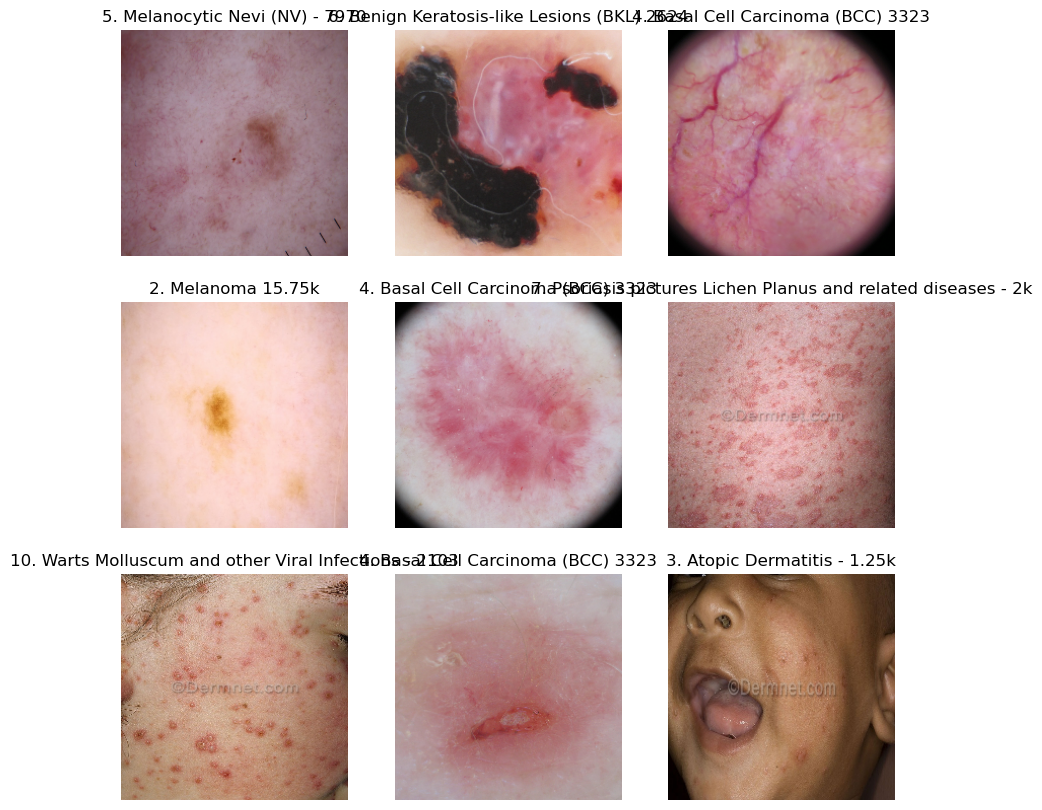

In [9]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

In [12]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [13]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        len(class_names),
        activation="softmax"
    )
])

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda (Lambda)                      │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │          12,810 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 225s 326ms/step - accuracy: 0.5385 - loss: 1.2733 - val_accuracy: 0.6055 - val_loss: 1.0267
Epoch 2/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 228s 335ms/step - accuracy: 0.6160 - loss: 1.0375 - val_accuracy: 0.6348 - val_loss: 0.9557
Epoch 3/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 234s 345ms/step - accuracy: 0.6226 - loss: 0.9936 - val_accuracy: 0.6392 - val_loss: 0.9591
Epoch 4/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 227s 334ms/step - accuracy: 0.6330 - loss: 0.9782 - val_accuracy: 0.6505 - val_loss: 0.9281
Epoch 5/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 224s 330ms/step - accuracy: 0.6367 - loss: 0.9690 - val_accuracy: 0.6578 - val_loss: 0.9139
Epoch 6/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 224s 330ms/step - accuracy: 0.6423 - loss: 0.9553 - val_accuracy: 0.6560 - val_loss: 0.9268
Epoch 7/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 226s 332ms/step - accuracy: 0.6400 - loss: 0.9490 - val_accuracy: 0.6532 - val_loss: 0.9413
Epoch 8/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 227s 335ms/step - accuracy: 0.6377 -

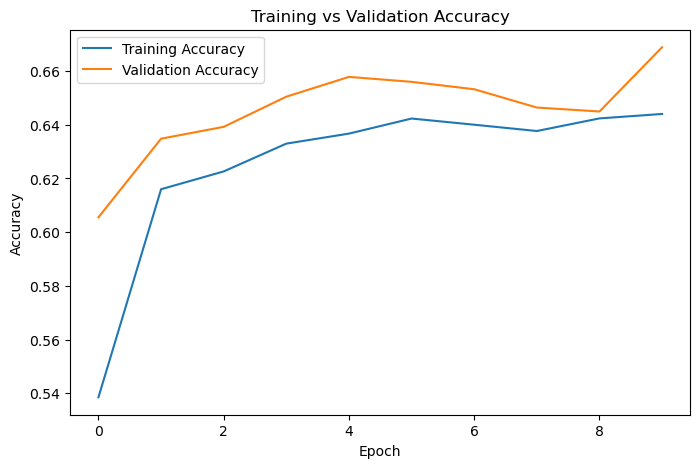

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

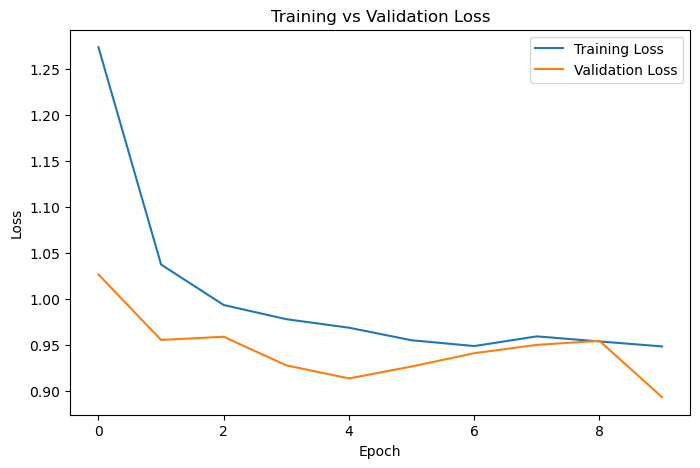

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()
# average model accuracy is 65% according to graphs

In [19]:
from pathlib import Path

for folder in Path(DATASET_DIR).iterdir():
    if folder.is_dir():
        count = len([
            f for f in folder.iterdir()
            if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
        ])
        print(f"{folder.name}: {count} images")

1. Eczema 1677: 1677 images
10. Warts Molluscum and other Viral Infections - 2103: 2103 images
2. Melanoma 15.75k: 3140 images
3. Atopic Dermatitis - 1.25k: 1257 images
4. Basal Cell Carcinoma (BCC) 3323: 3323 images
5. Melanocytic Nevi (NV) - 7970: 7970 images
6. Benign Keratosis-like Lesions (BKL) 2624: 2079 images
7. Psoriasis pictures Lichen Planus and related diseases - 2k: 2055 images
8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 1847 images
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 1702 images


###### from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=np.concatenate([
        labels.numpy()
        for _, labels in train_ds
    ])
)

class_weights = {
    i: weight
    for i, weight in enumerate(class_weights_array)
}

print("Class weights:")

for i, name in enumerate(class_names):
    print(f"{name}: {class_weights[i]:.3f}")

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights
)

Epoch 1/20
679/679 ━━━━━━━━━━━━━━━━━━━━ 225s 328ms/step - accuracy: 0.6175 - loss: 1.1744 - val_accuracy: 0.6302 - val_loss: 0.9688
Epoch 2/20
679/679 ━━━━━━━━━━━━━━━━━━━━ 226s 333ms/step - accuracy: 0.6183 - loss: 1.1672 - val_accuracy: 0.6446 - val_loss: 0.9242
Epoch 3/20
679/679 ━━━━━━━━━━━━━━━━━━━━ 222s 326ms/step - accuracy: 0.6208 - loss: 1.1530 - val_accuracy: 0.6383 - val_loss: 0.9499
Epoch 4/20
679/679 ━━━━━━━━━━━━━━━━━━━━ 223s 328ms/step - accuracy: 0.6235 - loss: 1.1527 - val_accuracy: 0.6506 - val_loss: 0.9240
Epoch 5/20
679/679 ━━━━━━━━━━━━━━━━━━━━ 222s 327ms/step - accuracy: 0.6196 - loss: 1.1420 - val_accuracy: 0.6495 - val_loss: 0.9406
Epoch 6/20
679/679 ━━━━━━━━━━━━━━━━━━━━ 222s 327ms/step - accuracy: 0.6239 - loss: 1.1410 - val_accuracy: 0.6448 - val_loss: 0.9629
Epoch 7/20
679/679 ━━━━━━━━━━━━━━━━━━━━ 243s 357ms/step - accuracy: 0.6192 - loss: 1.1528 - val_accuracy: 0.6396 - val_loss: 0.9541
Epoch 8/20
679/679 ━━━━━━━━━━━━━━━━━━━━ 224s 330ms/step - accuracy: 0.6243 -